# Wind Energy

## Learning goals

After this lesson you should be able to:

- explain why available wind power is proportional to the cube of wind speed;
- distinguish available power, rotor power, electrical power, rated power, and energy;
- apply the Betz limit without treating it as a real turbine efficiency;
- implement cut-in, rated, and cut-out behavior with Python conditionals;
- estimate hub-height wind speed, AEP, and capacity factor;
- work correctly with wind direction as circular data;
- produce and interpret power-curve and distribution plots.

Wind turbines convert part of the kinetic-energy flux through the rotor area into electricity. Real production depends on air density, wind speed at hub height, the turbine power curve, availability, wakes, electrical losses, curtailment, icing, and environmental limits. DOE describes the standard cut-in/rated/cut-out behavior, while Betz's ideal actuator-disk result bounds aerodynamic extraction [@doeWindWeather; @doeSmallWind].

<!-- expanded-theory:wind:start -->

## Physical description: extracting energy from moving air

Wind is air motion driven by atmospheric pressure gradients, with Earth's rotation, surface friction, terrain and thermal structure influencing the resulting flow. A turbine extracts part of the kinetic-energy flux passing through its rotor. The air must continue moving downstream; extracting all its kinetic energy at the rotor would prevent a continuing through-flow. This is why a rotor cannot convert all of the undisturbed wind power into shaft power [@manwell2009; @wagner2009].

Most modern large electricity-generating wind turbines use lift-producing blades. The relative flow over a blade section produces aerodynamic forces, whose tangential component drives the rotor. The turbine's mechanical and electrical systems then convert rotor torque into useful electrical output. The visible rotation of the blades is one stage of an integrated aerodynamic, structural, control and electrical system.

### Components and system boundaries

The conversion sequence is **undisturbed wind → rotor aerodynamic extraction → shaft and drivetrain → generator and power electronics → transformer and network**. A wind farm introduces another level: turbines interact through wakes and share electrical and operational infrastructure.

| Term or component | Definition and significance |
|---|---|
| Rotor swept area | Disk area through which the horizontal-axis rotor intercepts the flow, not the area of blade material |
| Hub height | Height of the rotor centre; a wind-speed measurement should identify its height |
| Nacelle | Housing for major drivetrain and generating equipment atop the tower |
| Gearbox or direct drive | Alternative arrangements relating rotor speed and generator operation |
| Pitch control | Adjustment of blade angle to regulate aerodynamic loading and power |
| Yaw control | Alignment of a horizontal-axis rotor with the incident wind direction |
| Rated electrical power | Specified output limit under defined operating conditions |
| Power curve | Relationship between wind speed and electrical output for a specified turbine and reference conditions |
| Wake | Downstream flow modified by energy extraction and rotor-generated turbulence |

Onshore and offshore machines use the same fundamental conversion relationships, but access, support structures, environmental loading and maintenance differ. A technology description is not enough to calculate production: the model also needs a resource time series or distribution and a suitable turbine power curve.

The supplied *Wind Energy Explained* is the principal reference for the physics and statistical treatment below. Wagner and Mathur offer a shorter introduction. The additional *Wind Energy Handbook* extends the reading to machine design, controls and wind-farm interactions [@manwell2009; @wagner2009; @burton2011wind; @burton2021wind].

## Deriving the main aerodynamic relationships

### Why available power contains the cube of wind speed

For air density $\rho$, uniform undisturbed speed $v$ and rotor area $A$, the mass crossing the area in one second is $\dot m=\rho Av$. The kinetic energy per unit mass is $v^2/2$. Multiplying the two gives

$$P_{wind}=\dot m\frac{v^2}{2}=\frac12\rho Av^3.$$

The cubic dependence combines two effects: faster air carries more kinetic energy per kilogram and more kilograms pass the rotor each second. At fixed density and area, doubling speed gives eight times the **available kinetic-energy flux**. It does not imply eight times electrical output once turbine operating limits are involved.

For a circular rotor, $A=\pi R^2=\pi D^2/4$. Doubling diameter gives four times the swept area, not twice the area. With density in kg/m³, area in m² and speed in m/s, power is watts. The relationship assumes a representative speed across the rotor; real shear, turbulence and spatial variation complicate that approximation [@manwell2009].

### Power coefficient, drivetrain efficiency and Betz's limit

The rotor power coefficient is

$$C_p=\frac{P_{rotor}}{\tfrac12\rho Av^3}.$$

It is an aerodynamic extraction ratio. A separate drivetrain/generator efficiency gives a simplified electrical relationship,

$$P_e=\eta_{drive}C_p\frac12\rho Av^3.$$

The ideal actuator-disk analysis yields $C_p\le16/27\approx0.593$ under its assumptions of steady, incompressible, unconfined ideal flow. The bound concerns power extracted from the undisturbed kinetic-energy flux. It is not a typical operating value, an electrical efficiency, or a capacity factor. Real rotors incur additional aerodynamic and mechanical losses [@manwell2009; @wagner2009].

Both $C_p$ and $\eta_{drive}$ can vary with operating point. If a supplied power curve already represents electrical output, do **not** multiply it by $C_p$ and generator efficiency again. First identify whether the input model describes wind power, rotor power, generator power or exported power.

### Torque and tip-speed ratio

Rotating-shaft power is

$$P_{shaft}=\tau\Omega,$$

where torque $\tau$ is N m and angular velocity $\Omega$ is radians/s. Convert rotational speed $n$ in revolutions/minute with $\Omega=2\pi n/60$. The tip-speed ratio is

$$\lambda=\frac{\Omega R}{v}.$$

It compares blade-tip speed with undisturbed wind speed. Aerodynamic performance depends on tip-speed ratio and blade pitch, commonly represented as $C_p(\lambda,\beta)$, where $\beta$ is pitch angle under the chosen convention. Variable-speed control can adjust rotor speed to operate efficiently below rated output; above rated conditions, pitch and other controls constrain power and structural loads. A constant $C_p$ approximation is therefore a learning model, not a complete control model [@manwell2009].

## Resource characterization: density, height and variability

### Air density

For an ideal dry-air approximation,

$$\rho=\frac{p}{R_dT},\qquad R_d\approx287.05\ \mathrm{J/(kg\,K)}.$$

Pressure $p$ is in pascals and absolute temperature $T$ is kelvin. Humidity and local conditions modify density; 1.225 kg/m³ is a stated reference assumption, not a universal site value. At fixed speed and swept area, lower density reduces available power. Applying a density adjustment to a manufacturer power curve requires that curve's specified correction procedure, especially near rated output [@manwell2009; @wagner2009].

### Wind shear and extrapolation to hub height

Surface friction and atmospheric structure produce a vertical wind profile. An often-used empirical approximation is

$$v(z)=v(z_r)\left(\frac{z}{z_r}\right)^\alpha.$$

Both heights must be positive and measured relative to a consistent reference; $\alpha$ is an assumed or fitted shear exponent. It changes with roughness, atmospheric stability and conditions. Treating 0.14 or $1/7$ as an immutable physical constant can introduce resource bias. The final project supplies hub-height wind speed, so applying another height correction there would double-adjust the data.

A neutral-atmosphere log-law model is another approximation,

$$v(z)=\frac{u_*}{\kappa}\ln\left(\frac{z-d}{z_0}\right),$$

where $u_*$ is friction velocity, $\kappa$ is the von Kármán constant, $z_0$ is roughness length and $d$ is displacement height. It requires an appropriate surface-layer setting and height range; it is not a universal replacement for the power law over complex terrain. The beginner calculations use the power law and explicitly state its exponent rather than fitting a more advanced atmospheric model without adequate data [@manwell2009].

### Turbulence, gusts and averaging

**Turbulence intensity** for a defined observation window is $TI=\sigma_v/\bar v$ for positive mean speed. State the sampling window, data filtering and standard-deviation convention. It describes variability relative to the mean, not the same quantity as a gust speed. Turbulence influences loads, fatigue and power fluctuations; an energy-only model does not assess structural safety.

For a nonlinear power model, $P(\bar v)$ is generally different from the average $\overline{P(v)}$. With equal-duration speeds of 4 and 8 m/s, the mean cubed speed is $(4^3+8^3)/2=288$, while the cube of the mean is $6^3=216$. Above rated speed or around cut-out, clipping and shutdown create further differences. Use interval data or an explicit probability distribution rather than assuming mean speed fully characterizes the resource.

## The electrical power curve

The course's idealized curve is

$$
P(v)=\begin{cases}
0,&v<v_{in},\\
P_r\dfrac{v^3-v_{in}^3}{v_r^3-v_{in}^3},&v_{in}\le v<v_r,\\
P_r,&v_r\le v<v_{out},\\
0,&v\ge v_{out}.
\end{cases}
$$

$v_{in}$ is cut-in speed, $v_r$ is rated speed, $v_{out}$ is cut-out speed, and $P_r$ is rated electrical power. These thresholds are turbine-specific. The ramp interpolates continuously between zero and rated power, while the ideal cut-out model has an abrupt shutdown. Actual controllers may use hysteresis, delayed restart, derating or different storm-control behavior. The simple curve teaches conditionals and boundary testing; it does not reproduce every modern controller [@manwell2009; @doeWindWeather].

Testing exactly at the thresholds is important. For the exercise convention, output is zero at cut-in, rated at rated speed, and zero at cut-out. Reject negative or non-finite resource inputs before calculating output. Do not permit an unconstrained cubic equation to predict power above the equipment limit.

## From resource distributions to annual energy

For interval-average modeled electrical power,

$$E=\sum_iP(v_i)\Delta t_i.$$

When speed is represented by a probability density $f(v)$ instead of an ordered time series,

$$\bar P=\int_0^\infty P(v)f(v)\,dv,\qquad E=T\bar P.$$

The integral averages **electrical power**, not wind speed. Use $T=8760$ h for a non-leap year only when that is the intended period. Multiplying a short or unrepresentative sample by annual hours is an extrapolation whose assumptions must be stated.

### Weibull resource model and numerical integration

A two-parameter Weibull model for nonnegative speed has cumulative distribution

$$F(v)=1-\exp[-(v/c)^k],$$

where $k>0$ is dimensionless shape and $c>0$ is scale in m/s. The probability of a bin $[a_i,b_i]$ is $p_i=F(b_i)-F(a_i)$. A midpoint approximation gives

$$\bar P\approx\sum_i P\!\left(\frac{a_i+b_i}{2}\right)p_i.$$

Bin probability is dimensionless, while density has inverse-speed units; they cannot be substituted for one another without the bin width. Refine the bins to check numerical convergence and account for the probability beyond the integration range. A Weibull fit is a statistical approximation, not a law that all sites must follow [@manwell2009].

### Losses, wakes and uncertainty

A downstream turbine may encounter reduced wind speed and altered turbulence due to an upstream wake. Wake interaction depends on direction, spacing, controls and atmospheric conditions. Other energy reductions include equipment downtime, electrical losses, icing and curtailment. A simple retained-energy factor can summarize explicitly stated assumptions, but it does not represent the detailed physics or hourly coincidence of those effects.

Separate variability from uncertainty. Weather changes from hour to hour and year to year; uncertainty also arises from measurement, long-term adjustment and modelling choices. In common wind-project terminology, an annual-energy **P90** is an energy level expected to be exceeded with 90% probability under the defined uncertainty model—thus a lower quantile than P50. It is not “90% of the mean.” Synthetic bootstrap or Monte Carlo exercises demonstrate methods; they do not create a bankable uncertainty estimate from a few invented observations.

## Wind direction and circular data

Meteorological direction convention normally describes where wind comes **from**, measured clockwise from north. Directions 350° and 10° are close together, even though their ordinary numerical difference is large. Compute an equal-weight circular mean using

$$\bar\theta=\operatorname{atan2}\!\left(\overline{\sin\theta},\overline{\cos\theta}\right),$$

then express it on the desired 0–360° interval. Convert degrees to radians before using NumPy trigonometric functions. The resultant length $R=\sqrt{\overline{\sin\theta}^{\,2}+\overline{\cos\theta}^{\,2}}$ measures directional concentration. If $R$ is near zero, the mean direction is unstable or undefined; opposing observations must not be assigned a spurious meaningful direction.

An equal-weight mean direction is not a speed-weighted vector-mean wind. For east/north velocity components under the meteorological “from” convention, $u=-v\sin\theta$ and $w_N=-v\cos\theta$. Distinguish these definitions when combining speed and direction. A wind rose groups directional frequencies, speed ranges or energy contributions; its weighting should be identified.

## Worked calculation before coding

Take a synthetic rotor radius of 20 m, density 1.225 kg/m³, undisturbed speed 8 m/s, $C_p=0.40$ and drivetrain efficiency 0.95.

1. Swept area is $\pi20^2\approx1256.64$ m².
2. Available wind power is $0.5(1.225)(1256.64)(8^3)\approx394{,}082$ W. Divide by 1000 to obtain **394.08 kW**.
3. Rotor extraction is about $0.40(394.08)=157.63$ kW.
4. Electrical output is about $0.95(157.63)=149.75$ kW before additional site losses or equipment limits.
5. At a constant mean electrical output of 149.75 kW for two hours, energy is about 299.5 kWh.

Check the ordering: electrical power is below rotor power, which is below available wind power. This example uses a fixed coefficient at one operating point; the piecewise electrical curve is a separate alternative model, not another factor to multiply into the same calculation.

## Environmental context and the route to Python

Wind-energy development must consider land or sea use, wildlife, noise, visual effects, access, materials and end-of-life management, as well as grid connection. A production calculation does not establish that a site is suitable. The supplementary *Wind Energy Handbook*, third edition, provides further reading on wakes, design loads, offshore structures and grid integration; its publisher information was checked for the reading list, not treated as a substitute for access to the full text [@burton2021wind].

Exercises 1–5 introduce area, kinetic power and conversion ratios. Exercises 6–15 develop resource adjustments, operating boundaries, statistics and direction. Exercises 16–20 integrate probability distributions, fitting, scenario comparisons and uncertainty methods. Read the supplied *Wind Energy Explained*, especially the wind-resource and aerodynamic discussions, before interpreting those models [@manwell2009; @wagner2009].


<!-- expanded-theory:wind:end -->

## Concepts and equations: compact reference

### Available wind power

Air moving at speed $v$ through swept area $A$ has available power

$$P_{wind}=\frac{1}{2}\rho A v^3,\qquad A=\pi R^2$$

Rotor power is

$$P_{rotor}=C_pP_{wind}$$

where $C_p$ is the power coefficient. The ideal Betz maximum is

$$C_{p,max}=\frac{16}{27}\approx0.593$$

This is an aerodynamic upper bound, not a typical electrical efficiency. Generator and drivetrain losses occur after aerodynamic extraction.

### Air density and hub height

At the same wind speed, available power scales linearly with air density. A basic pressure-temperature approximation is

$$\rho\approx\frac{p}{R_dT}$$

with dry-air gas constant $R_d=287.05$ J/(kg K), pressure in Pa, and temperature in K.

When only a reference-height wind speed is available, the empirical power law is often used:

$$v(z)=v(z_r)\left(\frac{z}{z_r}\right)^\alpha$$

The shear exponent $\alpha$ is site- and stability-dependent; it is not universally $1/7$.

### Power curve, AEP, and capacity factor

A simplified curve has four regions:

1. zero below cut-in speed;
2. increasing output between cut-in and rated speed;
3. rated output between rated and cut-out speed;
4. zero at and above cut-out speed.

For discrete wind states with probabilities $p_i$:

$$AEP=8760\sum_i P(v_i)p_i$$

and

$$CF=\frac{AEP}{P_r\,8760}$$

Use a manufacturer power curve for real AEP work. A cubic interpolation is a teaching approximation only.

## Tested Python functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def air_density_kgm3(pressure_pa, temperature_c):
    """Dry-air density from the ideal-gas approximation."""
    if not all(np.isfinite(np.asarray(value, dtype=float)).all() for value in [pressure_pa, temperature_c]):
        raise ValueError("model inputs must be finite")
    temperature_k = np.asarray(temperature_c, dtype=float) + 273.15
    if np.any(temperature_k <= 0) or np.any(np.asarray(pressure_pa) <= 0):
        raise ValueError("pressure and absolute temperature must be positive")
    return np.asarray(pressure_pa, dtype=float) / (287.05 * temperature_k)

def wind_at_height(speed_ref, height_m, ref_height_m=10, alpha=0.14):
    if not all(np.isfinite(np.asarray(value, dtype=float)).all() for value in [speed_ref, height_m, ref_height_m, alpha]):
        raise ValueError("model inputs must be finite")
    speed = np.asarray(speed_ref, dtype=float)
    if np.any(speed < 0) or np.any(np.asarray(height_m) <= 0) or np.any(np.asarray(ref_height_m) <= 0):
        raise ValueError("speeds must be non-negative and heights positive")
    return speed * (np.asarray(height_m) / np.asarray(ref_height_m)) ** alpha

def turbine_power_mw(speed_ms, rated_power_mw=3.0,
                     cut_in=3.0, rated_speed=12.0, cut_out=25.0):
    """Simplified continuous cubic power curve with correct boundaries."""
    if not all(np.isfinite(np.asarray(value, dtype=float)).all() for value in [speed_ms, rated_power_mw, cut_in, rated_speed, cut_out]):
        raise ValueError("model inputs must be finite")
    if not 0 <= cut_in < rated_speed < cut_out:
        raise ValueError("require 0 <= cut_in < rated_speed < cut_out")
    speed = np.asarray(speed_ms, dtype=float)
    if np.any(speed < 0) or rated_power_mw < 0:
        raise ValueError("speed and rated power must be non-negative")
    power = np.zeros_like(speed)
    ramp = (speed >= cut_in) & (speed < rated_speed)
    power[ramp] = rated_power_mw * (
        (speed[ramp] ** 3 - cut_in ** 3) /
        (rated_speed ** 3 - cut_in ** 3)
    )
    plateau = (speed >= rated_speed) & (speed < cut_out)
    power[plateau] = rated_power_mw
    return float(power) if power.ndim == 0 else power

assert turbine_power_mw(2) == 0
assert turbine_power_mw(12) == 3
assert turbine_power_mw(25) == 0

## Worked distribution and AEP example

The Weibull probability density is

$$f(v)=\frac{k}{c}\left(\frac{v}{c}\right)^{k-1}
\exp\left[-\left(\frac{v}{c}\right)^k\right]$$

where $k$ is shape and $c$ is scale. A fitted distribution compresses information and may miss calm periods, storms, seasonality, and direction-dependent wakes.

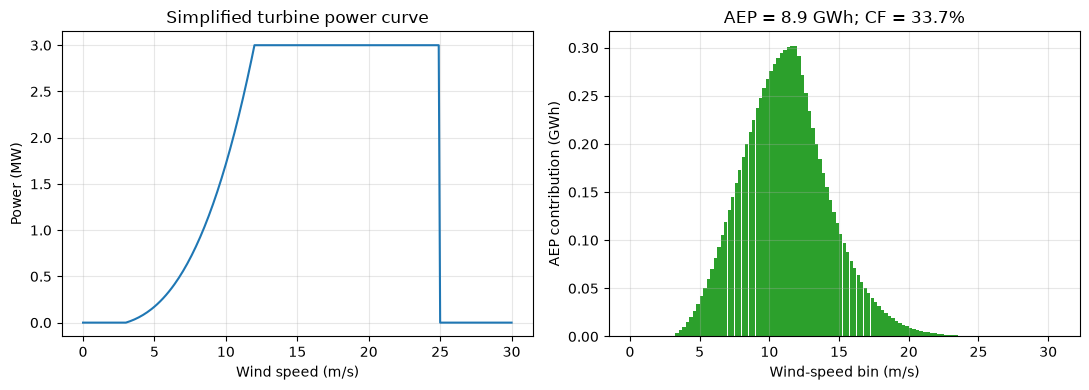

In [2]:
def weibull_pdf(speed_ms, shape_k, scale_c):
    speed = np.asarray(speed_ms, dtype=float)
    if shape_k <= 0 or scale_c <= 0 or np.any(speed < 0):
        raise ValueError("Weibull parameters must be positive; speed non-negative")
    return (shape_k / scale_c) * (speed / scale_c) ** (shape_k - 1) * np.exp(
        -(speed / scale_c) ** shape_k
    )

bin_edges = np.arange(0, 31, 0.25)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
k, c = 2.1, 8.5
cdf = lambda v: 1 - np.exp(-(v / c) ** k)
probability = cdf(bin_edges[1:]) - cdf(bin_edges[:-1])
power_mw = turbine_power_mw(bin_centres)
aep_mwh = np.sum(power_mw * probability) * 8760
capacity_factor = aep_mwh / (3.0 * 8760)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
speed_grid = np.linspace(0, 30, 301)
axes[0].plot(speed_grid, turbine_power_mw(speed_grid), color="tab:blue")
axes[0].set(xlabel="Wind speed (m/s)", ylabel="Power (MW)",
            title="Simplified turbine power curve")
axes[1].bar(bin_centres, power_mw * probability * 8760 / 1000,
            width=0.24, color="tab:green")
axes[1].set(xlabel="Wind-speed bin (m/s)", ylabel="AEP contribution (GWh)",
            title=f"AEP = {aep_mwh/1000:.1f} GWh; CF = {capacity_factor:.1%}")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()

## Wind direction is circular

Meteorological wind direction states where wind comes **from**: 0° is north and 90° is east. Arithmetic means fail near north—for example, 350° and 10° average to 180° arithmetically even though both are northerly. Use vector components:

$$\bar\theta=\operatorname{atan2}(\overline{\sin\theta},
\overline{\cos\theta})$$

and wrap the result to $[0,360)$.

In [3]:
def circular_mean_degrees(direction_deg):
    values = np.asarray(direction_deg, dtype=float)
    if values.size == 0 or not np.isfinite(values).all():
        raise ValueError("directions must be nonempty and finite")
    radians = np.deg2rad(values)
    if np.hypot(np.sin(radians).mean(), np.cos(radians).mean()) < 1e-12:
        raise ValueError("mean direction is undefined for cancelling vectors")
    angle = np.rad2deg(np.arctan2(np.mean(np.sin(radians)),
                                  np.mean(np.cos(radians))))
    return np.round(angle % 360, 12) % 360

assert np.isclose(circular_mean_degrees([350, 10]), 0)

[Download this complete chapter as a Jupyter notebook](windEnergy.ipynb). In standard Jupyter viewers, answer headings and code are visible below each prompt; the book provides collapse controls.

## Chapter practice — 20 Python exercises

**5 easy · 10 medium · 5 hard.** Work through the exercises in order. All inputs are synthetic teaching data. Each solution is directly below its question and starts collapsed in the book. Open it after trying your own code. Each solution runs independently; run the full notebook from the first cell when studying the chapter. References identify the underlying concepts rather than copied textbook problems.

### Exercise 01 — Rotor swept area

**Difficulty:** Easy

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Calculate swept area for a 20 m radius rotor using pi r².

In [4]:
# Your solution for wind exercise 01.

#### Step-by-step answer — Wind 01

1. Enter the rotor radius in metres.
2. Calculate the swept disk area.
3. Check against diameter-based area.

In [5]:
import math
# Step 1: Enter the rotor radius in metres.
radius=20
# Step 2: Calculate the swept disk area.
area=math.pi*radius**2
# Step 3: Check against diameter-based area.
print(area,'m²'); assert math.isclose(area,math.pi*(2*radius)**2/4)

1256.6370614359173 m²


**Interpretation:** Use rotor swept area, not blade material area.


### Exercise 02 — Available wind power

**Difficulty:** Easy

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Use density 1.225 kg/m³, area 1000 m² and speed 8 m/s. Calculate available wind kW.

In [6]:
# Your solution for wind exercise 02.

#### Step-by-step answer — Wind 02

1. Enter resource parameters in SI units.
2. Calculate kinetic-energy flux through the rotor area.
3. Check the numerical result.

In [7]:
# Step 1: Enter resource parameters in SI units.
rho,area,speed=1.225,1000,8
# Step 2: Calculate kinetic-energy flux through the rotor area.
available_kw=0.5*rho*area*speed**3/1000
# Step 3: Check the numerical result.
print(available_kw,'kW'); assert abs(available_kw-313.6)<1e-10

313.6 kW


**Interpretation:** 313.6 kW is available in the wind, not electrical output.


### Exercise 03 — Cubic speed sensitivity

**Difficulty:** Easy

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Compare available power at 5 and 10 m/s for the same rotor and density. Calculate their ratio.

In [8]:
# Your solution for wind exercise 03.

#### Step-by-step answer — Wind 03

1. Store the two speeds.
2. Cancel common factors and compare cubed speeds.
3. Verify the effect of doubling speed.

In [9]:
# Step 1: Store the two speeds.
low,high=5,10
# Step 2: Cancel common factors and compare cubed speeds.
ratio=high**3/low**3
# Step 3: Verify the effect of doubling speed.
print(ratio,'times'); assert ratio==8

8.0 times


**Interpretation:** A real turbine does not keep increasing output cubically above rated speed.


### Exercise 04 — Aerodynamic extraction

**Difficulty:** Easy

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Available wind power is 500 kW, Cp 0.4 and drivetrain efficiency 0.95. Find electrical kW and compare Cp with 16/27.

In [10]:
# Your solution for wind exercise 04.

#### Step-by-step answer — Wind 04

1. Specify power and fractional conversion factors.
2. Apply aerodynamic extraction and drivetrain losses.
3. Check the ideal Betz bound and the result.

In [11]:
# Step 1: Specify power and fractional conversion factors.
available,cp,efficiency=500,0.4,0.95
# Step 2: Apply aerodynamic extraction and drivetrain losses.
electrical=available*cp*efficiency
# Step 3: Check the ideal Betz bound and the result.
print(electrical,'kW'); assert cp<16/27 and electrical==190

190.0 kW


**Interpretation:** Betz is an ideal aerodynamic limit; it is not a turbine capacity factor.


### Exercise 05 — Daily turbine capacity factor

**Difficulty:** Easy

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** A 3 MW turbine delivers 21.6 MWh in 24 h. Calculate daily CF.

In [12]:
# Your solution for wind exercise 05.

#### Step-by-step answer — Wind 05

1. Calculate the rated energy for the same interval.
2. Divide measured energy by rated energy.
3. Print the percentage and check bounds.

In [13]:
# Step 1: Calculate the rated energy for the same interval.
maximum=3*24
# Step 2: Divide measured energy by rated energy.
cf=21.6/maximum
# Step 3: Print the percentage and check bounds.
print(f'{cf:.0%}'); assert abs(cf-0.3)<1e-12

30%


**Interpretation:** 30% is a period-specific utilization measure.


### Exercise 06 — Hub-height adjustment

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Wind is 6 m/s at 10 m. Estimate at heights[10,50,100] m using v=vref(z/zref)^0.14.

In [14]:
# Your solution for wind exercise 06.

#### Step-by-step answer — Wind 06

1. Store measurement height, speed and target heights.
2. Apply the assumed power-law shear profile.
3. Verify the reference height is unchanged.

In [15]:
import numpy as np
# Step 1: Store measurement height, speed and target heights.
height=np.array([10,50,100]); reference=10; speed=6
# Step 2: Apply the assumed power-law shear profile.
hub=speed*(height/reference)**0.14
# Step 3: Verify the reference height is unchanged.
print(hub,'m/s'); assert hub[0]==6 and np.all(np.diff(hub)>0)

[6.         7.51635097 8.28230559] m/s


**Interpretation:** The exponent is illustrative and not universal across terrain and atmospheric stability.


### Exercise 07 — Density sensitivity

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** At fixed area 1000 m² and 8 m/s, compare available kW for densities[1.0,1.225,1.3] kg/m³.

In [16]:
# Your solution for wind exercise 07.

#### Step-by-step answer — Wind 07

1. Store candidate air densities.
2. Keep geometry and speed fixed.
3. Check proportionality with density.

In [17]:
import numpy as np
# Step 1: Store candidate air densities.
rho=np.array([1.0,1.225,1.3])
# Step 2: Keep geometry and speed fixed.
power=0.5*rho*1000*8**3/1000
# Step 3: Check proportionality with density.
print(power,'kW'); assert np.allclose(power/power[0],rho/rho[0])

[256.  313.6 332.8] kW


**Interpretation:** This checks available wind power; manufacturer electrical curves require their specified density treatment.


### Exercise 08 — Piecewise turbine curve

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Implement 3 MW rated power: zero below 3 m/s, 3(v³−3³)/(12³−3³) between 3 and 12, rated to below 25, zero thereafter. Test[0,3,6,12,25].

In [18]:
# Your solution for wind exercise 08.

#### Step-by-step answer — Wind 08

1. Define a vectorised curve with explicit operating boundaries.
2. Evaluate boundary and intermediate speeds.
3. Check key thresholds and print MW.

In [19]:
import numpy as np
# Step 1: Define a vectorised curve with explicit operating boundaries.
def curve(values):
    v=np.asarray(values,dtype=float)
    if np.any(~np.isfinite(v)) or np.any(v<0): raise ValueError('Invalid wind speed')
    return np.where((v>=3)&(v<12),3*(v**3-3**3)/(12**3-3**3),np.where((v>=12)&(v<25),3.,0.))
# Step 2: Evaluate boundary and intermediate speeds.
power=curve([0,3,6,12,25])
# Step 3: Check key thresholds and print MW.
print(power,'MW'); assert np.allclose(power[[0,1,3,4]],[0,0,3,0])

[0.         0.         0.33333333 3.         0.        ] MW


**Interpretation:** Cut-out is a shutdown boundary; the idealised curve omits control hysteresis.


### Exercise 09 — Power of mean versus mean power

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Compare the mean of v³ with the cube of mean speed for speeds[4,8] m/s.

In [20]:
# Your solution for wind exercise 09.

#### Step-by-step answer — Wind 09

1. Store equal-duration wind observations.
2. Compare averaging before and after the nonlinear transformation.
3. Print the discrepancy and check its direction.

In [21]:
import numpy as np
# Step 1: Store equal-duration wind observations.
v=np.array([4,8])
# Step 2: Compare averaging before and after the nonlinear transformation.
mean_cube=np.mean(v**3); cube_mean=np.mean(v)**3
# Step 3: Print the discrepancy and check its direction.
print(mean_cube,cube_mean,'m³/s³'); assert mean_cube==288 and cube_mean==216

288.0 216.0 m³/s³


**Interpretation:** Using mean speed in a nonlinear power model can bias energy estimates; clipping adds further effects.


### Exercise 10 — Turbulence intensity

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** For[6,8,10] m/s, calculate population standard deviation divided by mean speed. State ddof=0.

In [22]:
# Your solution for wind exercise 10.

#### Step-by-step answer — Wind 10

1. Define the observations and statistical convention.
2. Divide population standard deviation by nonzero mean.
3. Check and print the dimensionless ratio.

In [23]:
import numpy as np
# Step 1: Define the observations and statistical convention.
v=np.array([6,8,10]); mean=v.mean()
# Step 2: Divide population standard deviation by nonzero mean.
ti=v.std(ddof=0)/mean
# Step 3: Check and print the dimensionless ratio.
print(f'TI: {ti:.2%}'); assert np.isclose(ti,np.sqrt(8/3)/8)

TI: 20.41%


**Interpretation:** Three samples demonstrate the calculation; they do not meet a field measurement campaign specification.


### Exercise 11 — Circular mean direction

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Calculate the equal-weight circular mean of[350,10,0] degrees clockwise from north.

In [24]:
# Your solution for wind exercise 11.

#### Step-by-step answer — Wind 11

1. Convert angles to radians before trigonometry.
2. Average sine and cosine and recover a compass angle.
3. Verify north modulo a full rotation.

In [25]:
import numpy as np
# Step 1: Convert angles to radians before trigonometry.
angle=np.deg2rad([350,10,0])
# Step 2: Average sine and cosine and recover a compass angle.
s=np.sin(angle).mean(); c=np.cos(angle).mean()
mean=np.degrees(np.arctan2(s,c))%360
# Step 3: Verify north modulo a full rotation.
print(mean,'degrees'); assert min(abs(mean),abs(mean-360))<1e-10

360.0 degrees


**Interpretation:** An arithmetic mean would be misleading across the north/360° boundary.


### Exercise 12 — Compass sector counts

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Bin directions[350,0,20,45,90,180,270] into eight sectors centered on N,NE,E,SE,S,SW,W,NW.

In [26]:
# Your solution for wind exercise 12.

#### Step-by-step answer — Wind 12

1. Shift by half a sector so north straddles zero degrees.
2. Count each sector including empty ones.
3. Check all records are counted and north has three.

In [27]:
import numpy as np
# Step 1: Shift by half a sector so north straddles zero degrees.
direction=np.array([350,0,20,45,90,180,270]); sector=((direction+22.5)%360//45).astype(int)
# Step 2: Count each sector including empty ones.
counts=np.bincount(sector,minlength=8)
# Step 3: Check all records are counted and north has three.
print(dict(zip(['N','NE','E','SE','S','SW','W','NW'],counts)))
assert counts.sum()==7 and counts[0]==3

{'N': 3, 'NE': 1, 'E': 1, 'SE': 0, 'S': 1, 'SW': 0, 'W': 1, 'NW': 0}


**Interpretation:** These are frequency counts, not energy-weighted wind-rose sectors.


### Exercise 13 — Combined availability and losses

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Gross annual energy is 10 GWh. Apply availability 0.97 and retained wake energy 0.92 sequentially.

In [28]:
# Your solution for wind exercise 13.

#### Step-by-step answer — Wind 13

1. Store independent retained-energy assumptions.
2. Apply each factor once.
3. Check net energy and show the total loss fraction.

In [29]:
# Step 1: Store independent retained-energy assumptions.
gross=10; availability=0.97; wake_retained=0.92
# Step 2: Apply each factor once.
net=gross*availability*wake_retained
# Step 3: Check net energy and show the total loss fraction.
print(net,'GWh; loss fraction:',1-net/gross); assert abs(net-8.924)<1e-12

8.924 GWh; loss fraction: 0.10760000000000003


**Interpretation:** Avoid applying a loss twice when an input power curve or energy estimate is already net of it.


### Exercise 14 — Unequal operating intervals

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Mean powers[0.5,2,3] MW last[2,1,0.5] hours. Calculate energy and CF for a 3 MW turbine.

In [30]:
# Your solution for wind exercise 14.

#### Step-by-step answer — Wind 14

1. Store aligned power and duration values.
2. Integrate and use the same duration in the capacity-factor denominator.
3. Check the hand sum and report results.

In [31]:
import numpy as np
# Step 1: Store aligned power and duration values.
p=np.array([0.5,2,3]); dt=np.array([2,1,0.5])
# Step 2: Integrate and use the same duration in the capacity-factor denominator.
energy=np.sum(p*dt); cf=energy/(3*dt.sum())
# Step 3: Check the hand sum and report results.
print(energy,'MWh;',cf,'CF'); assert energy==4.5 and 0<=cf<=1

4.5 MWh; 0.42857142857142855 CF


**Interpretation:** The energy-weighted time calculation is essential when intervals differ.


### Exercise 15 — Histogram of wind speeds

**Difficulty:** Medium

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Plot a histogram of[0,2,4,6,8,10,12,14] m/s with bins[0,5,10,15]. Check counts.

In [32]:
# Your solution for wind exercise 15.

#### Step-by-step answer — Wind 15

1. Specify speeds and bin edges.
2. Count observations and plot frequency.
3. Check bin counts and completeness.

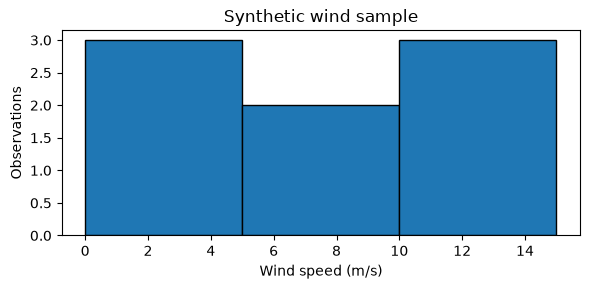

[3 2 3]


In [33]:
import numpy as np
import matplotlib.pyplot as plt
# Step 1: Specify speeds and bin edges.
speed=np.array([0,2,4,6,8,10,12,14]); edges=[0,5,10,15]
# Step 2: Count observations and plot frequency.
counts,_=np.histogram(speed,bins=edges)
fig,ax=plt.subplots(figsize=(6,3)); ax.hist(speed,bins=edges,edgecolor='black')
ax.set(xlabel='Wind speed (m/s)',ylabel='Observations',title='Synthetic wind sample'); fig.tight_layout(); plt.show()
# Step 3: Check bin counts and completeness.
print(counts); assert np.array_equal(counts,[3,2,3])

**Interpretation:** A frequency histogram uses counts; probability density would have a different vertical-axis unit.


### Exercise 16 — Weibull annual energy and convergence

**Difficulty:** Hard

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Use Weibull shape 2, scale 8 m/s and the 3/12/25 m/s,3 MW curve. Integrate using midpoint powers and CDF bin probabilities over 0–30 m/s. Compare bin widths 0.1 and 0.05; apply 8760 h and net factor 0.9.

In [34]:
# Your solution for wind exercise 16.

#### Step-by-step answer — Wind 16

1. Define the curve and exact bin probabilities from the Weibull CDF.
2. Refine the integration grid.
3. Check convergence and capacity limits.

In [35]:
import numpy as np
# Step 1: Define the curve and exact bin probabilities from the Weibull CDF.
def aep(step):
    edges=np.arange(0,30+step/2,step); mid=(edges[:-1]+edges[1:])/2
    probability=np.diff(1-np.exp(-(edges/8)**2))
    p=np.where((mid>=3)&(mid<12),3*(mid**3-27)/(1728-27),np.where((mid>=12)&(mid<25),3,0))
    return np.sum(p*probability)*8760*0.9/1000
# Step 2: Refine the integration grid.
coarse,fine=aep(0.1),aep(0.05)
# Step 3: Check convergence and capacity limits.
print(coarse,fine,'GWh; relative difference:',abs(coarse-fine)/fine)
assert abs(coarse-fine)/fine<0.001 and 0<fine<3*8760/1000

7.108167688868485 7.108158111121829 GWh; relative difference: 1.3474301649584582e-06


**Interpretation:** Probability above30 m/s has zero output under this shutdown curve; its omission does not remove generating energy.


### Exercise 17 — Undefined circular means

**Difficulty:** Hard

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Write a direction-mean function rejecting empty/nonfinite data and resultant length below 1e−8. Verify[90,270] is undefined and[350,10] is north.

In [36]:
# Your solution for wind exercise 17.

#### Step-by-step answer — Wind 17

1. Validate input angles and compute the mean vector.
2. Verify cancellation is explicitly reported.
3. Verify the well-defined northward sample.

In [37]:
import numpy as np
# Step 1: Validate input angles and compute the mean vector.
def mean_direction(values):
    a=np.asarray(values,dtype=float)
    if a.size==0 or np.any(~np.isfinite(a)): raise ValueError('Need finite directions')
    s=np.sin(np.deg2rad(a)).mean(); c=np.cos(np.deg2rad(a)).mean()
    if np.hypot(s,c)<1e-8: raise ValueError('Undefined mean direction')
    return np.degrees(np.arctan2(s,c))%360
# Step 2: Verify cancellation is explicitly reported.
try: mean_direction([90,270])
except ValueError: print('Opposite directions: undefined mean')
else: raise AssertionError('Cancellation was not detected')
# Step 3: Verify the well-defined northward sample.
answer=mean_direction([350,10]); assert min(answer,360-answer)<1e-8
print(answer,'degrees')

Opposite directions: undefined mean
360.0 degrees


**Interpretation:** A near-zero resultant is not evidence for a meaningful northward average.


### Exercise 18 — Fit shear from multiple heights

**Difficulty:** Hard

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Measured speeds at heights[20,40,80] m are generated by 6(z/20)^0.2. Fit log(v) against log(z/20) and predict at 100 m.

In [38]:
# Your solution for wind exercise 18.

#### Step-by-step answer — Wind 18

1. Build synthetic multi-height observations.
2. Estimate exponent and reference speed by log-linear regression.
3. Recover the known synthetic parameters.

In [39]:
import numpy as np
# Step 1: Build synthetic multi-height observations.
height=np.array([20,40,80]); speed=6*(height/20)**0.2
# Step 2: Estimate exponent and reference speed by log-linear regression.
alpha,intercept=np.polyfit(np.log(height/20),np.log(speed),1)
prediction=np.exp(intercept)*(100/20)**alpha
# Step 3: Recover the known synthetic parameters.
print('Alpha:',alpha,'100 m wind:',prediction,'m/s')
assert np.isclose(alpha,0.2) and np.isclose(np.exp(intercept),6)

Alpha: 0.20000000000000065 100 m wind: 8.278377968767293 m/s


**Interpretation:** Three heights provide a fit and consistency check; real profiles require concurrent quality-controlled measurements.


### Exercise 19 — Compare hub heights on energy

**Difficulty:** Hard

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** At 10 m, speeds[3,5,7,9] m/s last 6 h each. Compare hub heights 50 and 100 m using exponent 0.14 and the 3 MW piecewise curve. Calculate daily MWh, not power from mean speed.

In [40]:
# Your solution for wind exercise 19.

#### Step-by-step answer — Wind 19

1. Define the common measured speeds and a turbine model.
2. Adjust each interval to each candidate hub height.
3. Check rated bounds and compare the designs.

In [41]:
import numpy as np
# Step 1: Define the common measured speeds and a turbine model.
vref=np.array([3,5,7,9])
def curve(v):
    return np.where((v>=3)&(v<12),3*(v**3-27)/(1728-27),np.where((v>=12)&(v<25),3,0))
# Step 2: Adjust each interval to each candidate hub height.
energy={height:float(curve(vref*(height/10)**0.14).sum()*6) for height in [50,100]}
# Step 3: Check rated bounds and compare the designs.
print(energy,'MWh'); assert all(0<=e<=72 for e in energy.values()) and energy[100]>=energy[50]

{50: 24.320579136642586, 100: 30.920451386118664} MWh


**Interpretation:** Higher towers change cost and loads. More energy in this sample does not prove economic superiority.


### Exercise 20 — Bootstrap a sample mean power

**Difficulty:** Hard

**Reference:** Wind resource, aerodynamics and energy estimation: [@manwell2009], Chapters 2–3; turbine operation [@wagner2009].

**Task:** Observed daily-average powers[0.4,0.8,1.2,0.6,1.5,1.0] MW are treated as independent. With seed 11, bootstrap 2000 equal-sized samples and calculate a percentile 95% interval for mean MW.

In [42]:
# Your solution for wind exercise 20.

#### Step-by-step answer — Wind 20

1. Set observations and a reproducible random generator.
2. Resample observations with replacement and average each sample.
3. Check interval order and report the sampling assumptions.

In [43]:
import numpy as np
# Step 1: Set observations and a reproducible random generator.
p=np.array([0.4,0.8,1.2,0.6,1.5,1.0]); rng=np.random.default_rng(11)
# Step 2: Resample observations with replacement and average each sample.
means=rng.choice(p,size=(2000,len(p)),replace=True).mean(axis=1)
interval=np.quantile(means,[0.025,0.975])
# Step 3: Check interval order and report the sampling assumptions.
print('Sample mean:',p.mean(),'MW; bootstrap interval:',interval,'MW')
assert interval[0]<interval[1] and means.min()>=p.min() and means.max()<=p.max()

Sample mean: 0.9166666666666666 MW; bootstrap interval: [0.63333333 1.23333333] MW


**Interpretation:** Six days are insufficient for a bankable resource estimate. Serial dependence would require a suitable block bootstrap or another model.


## Common mistakes

- Using $v^2$ rather than $v^3$ in available wind power.
- Treating the Betz limit as turbine electrical efficiency.
- Extending the cubic law beyond rated speed or through cut-out.
- Calculating energy from mean wind speed; because of the cubic relationship, $P(\bar v)$ generally differs from $\overline{P(v)}$.
- Randomly shuffling time-series data before forecasting.
- Averaging wind directions arithmetically or reversing the meteorological convention.

## Check your understanding

Continue with the [wind-physics quiz](../section7/renewableEnergyquizzes/windEnergy.md) and the [wind data lab](../section7/renewableEnergyquizzes/eolicenergy.md).

## References used in this notebook

- **burton2011wind:** Burton, Tony and Jenkins, Nick and Sharpe, David and Bossanyi, Ervin. Wind Energy Handbook (2011). 
- **burton2021wind:** Burton, Tony L. and Jenkins, Nick and Bossanyi, Ervin and Sharpe, David and Graham, Michael. Wind Energy Handbook (2021). https://www.wiley-vch.de/en/areas-interest/engineering/energy-10eg/renewable-energy-10eg3/wind-energy-10eg35/wind-energy-handbook-978-1-119-45109-9
- **doeWindWeather:** U.S. Department of Energy. How Do Wind Turbines Survive Severe Weather and Storms? (2024). https://www.energy.gov/cmei/wind/articles/how-do-wind-turbines-survive-severe-weather-and-storms
- **doeSmallWind:** U.S. Department of Energy. Small Wind Guidebook (2025). https://www.energy.gov/cmei/systems/windexchange/small-wind-guidebook
- **wagner2009:** Wagner, Hermann-Josef and Mathur, Jyotirmay. Introduction to Wind Energy Systems: Basics, Technology and Operation (2009). 
- **manwell2009:** Manwell, James F. and McGowan, Jon G. and Rogers, Anthony L.. Wind Energy Explained: Theory, Design and Application (2009). 